# 🚀 PROJECT TITLE

## 💼 Job Listings Analysis Using Web Scraping

In [1]:
!pip install requests
!pip install beautifulsoup4
!pip install pandas

# 📚IMPORT LIBRARIES

In [3]:
import numpy as np
import pandas as pd

import requests
from bs4 import BeautifulSoup

import re

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In this section, we import all the libraries required for web scraping, data cleaning, data analysis, and data visualization.

- Requests → Connect to the website
- BeautifulSoup → Extract website data
- Pandas → Data manipulation
- NumPy → Numerical operations
- Matplotlib & Seaborn → Visualization

# 🌐WEBSITE CONNECTION

In [4]:
url = "https://realpython.github.io/fake-jobs/"

response = requests.get(url)

response

<Response [200]>

This step establishes a connection with the target website using the Requests library.

A response status code of 200 indicates that the website is accessible and ready for scraping.

# 🔍CHECK WEBSITE CONTENT

In [5]:
response.text[:500]

'<!DOCTYPE html>\n<html>\n  <head>\n    <meta charset="utf-8">\n    <meta name="viewport" content="width=device-width, initial-scale=1">\n    <title>Fake Python</title>\n    <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bulma@0.9.2/css/bulma.min.css">\n  </head>\n  <body>\n  <section class="section">\n    <div class="container mb-5">\n      <h1 class="title is-1">\n        Fake Python\n      </h1>\n      <p class="subtitle is-3">\n        Fake Jobs for Your Web Scraping Journey\n      </p>\n    </div>'

Before scraping, it is important to inspect the website content.

This helps verify that the HTML source has been loaded successfully.

# 🍲CREATE BEAUTIFULSOUP OBJECT

In [6]:
html_content = response.text

soup = BeautifulSoup(
    html_content,
    "html.parser"
)

soup.title.text

'Fake Python'



BeautifulSoup converts raw HTML into a structured format.

This allows us to locate and extract specific information from the webpage efficiently.

# 📦EXTRACT JOB CARDS

In [7]:
job_cards = soup.find_all(
    "div",
    class_="card-content"
)

print("Total Job Listings :", len(job_cards))

Total Job Listings : 100


Each job listing is stored inside a job card.

This step identifies all available job cards that contain the required information.

# 📋SCRAPE JOB DETAILS

In [8]:
jobs = []

for job in job_cards:

    title = job.find("h2").text.strip()

    company = job.find("h3").text.strip()

    location = job.find(
        "p",
        class_="location"
    ).text.strip()

    date_posted = job.find(
        "time"
    ).text.strip()

    jobs.append(
        [
            title,
            company,
            location,
            date_posted
        ]
    )

The required fields are extracted from each job card.

Collected information includes:

- Job Title
- Company Name
- Location
- Date Posted

The extracted data is stored inside a Python list.

# 🏗️ CREATE DATAFRAME

In [9]:
df = pd.DataFrame(
    jobs,
    columns=[
        "Job Title",
        "Company",
        "Location",
        "Date Posted"
    ]
)

df.head()

,Job Title,Company,Location,Date Posted
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",2021-04-08
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",2021-04-08
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",2021-04-08
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",2021-04-08
4,Product manager,Ramirez Inc,"North Jamieview, AP",2021-04-08


The extracted data is converted into a Pandas DataFrame.

A DataFrame provides a structured tabular format for further analysis.

# 💾SAVE RAW DATASET

In [10]:
df.to_csv(
    "raw_job_listing.csv",
    index=False
)

The scraped data is saved as a raw CSV file.

This dataset represents the original data collected directly from the website before any cleaning or preprocessing.

# 🔎UNDERSTAND DATASET

In [11]:
df.shape

(100, 4)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Job Title    100 non-null    object
 1   Company      100 non-null    object
 2   Location     100 non-null    object
 3   Date Posted  100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


In [13]:
df.head()

,Job Title,Company,Location,Date Posted
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",2021-04-08
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",2021-04-08
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",2021-04-08
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",2021-04-08
4,Product manager,Ramirez Inc,"North Jamieview, AP",2021-04-08


Initial dataset exploration is performed to understand:

- Number of rows and columns
- Data types
- Overall dataset structure

This helps identify potential data quality issues.

# 🧹MISSING VALUES

In [14]:
df.isnull().sum()

Job Title      0
Company        0
Location       0
Date Posted    0
dtype: int64

Missing values can impact data quality and analysis.

This step helps identify incomplete records within the dataset.

# 🔄HANDLE MISSING VALUES

In [15]:
df["Company"].fillna(
    df["Company"].mode()[0],
    inplace=True
)

df["Location"].fillna(
    df["Location"].mode()[0],
    inplace=True
)

In [16]:
df.isnull().sum()

Job Title      0
Company        0
Location       0
Date Posted    0
dtype: int64

Missing values are handled using suitable replacement techniques.

This improves dataset completeness and reliability.

# 🗑️ DUPLICATE CHECK

In [17]:
df.duplicated().sum()

np.int64(0)

Duplicate records may distort analysis results.

This step identifies duplicate entries present in the dataset.

# 🗑️REMOVE DUPLICATES

In [18]:
df.drop_duplicates(
    inplace=True
)

df.reset_index(
    drop=True,
    inplace=True
)

Duplicate records are removed to ensure data accuracy and consistency.

# 🧽TEXT CLEANING

In [19]:
df["Job Title"] = (
    df["Job Title"]
    .str.strip()
    .str.title()
)

df["Company"] = (
    df["Company"]
    .str.strip()
    .str.title()
)

df["Location"] = (
    df["Location"]
    .str.strip()
    .str.title()
)

In [20]:
df.head()

,Job Title,Company,Location,Date Posted
0,Senior Python Developer,"Payne, Roberts And Davis","Stewartbury, Aa",2021-04-08
1,Energy Engineer,Vasquez-Davidson,"Christopherville, Aa",2021-04-08
2,Legal Executive,"Jackson, Chambers And Levy","Port Ericaburgh, Aa",2021-04-08
3,Fitness Centre Manager,Savage-Bradley,"East Seanview, Ap",2021-04-08
4,Product Manager,Ramirez Inc,"North Jamieview, Ap",2021-04-08


Text values are standardized by:

- Removing unnecessary spaces
- Applying consistent formatting
- Improving data quality

This ensures uniformity across all text columns.

# 💾SAVE CLEAN DATASET

In [21]:
df.to_csv(
    "clean_job_listing.csv",
    index=False
)

In [22]:
df.head()

,Job Title,Company,Location,Date Posted
0,Senior Python Developer,"Payne, Roberts And Davis","Stewartbury, Aa",2021-04-08
1,Energy Engineer,Vasquez-Davidson,"Christopherville, Aa",2021-04-08
2,Legal Executive,"Jackson, Chambers And Levy","Port Ericaburgh, Aa",2021-04-08
3,Fitness Centre Manager,Savage-Bradley,"East Seanview, Ap",2021-04-08
4,Product Manager,Ramirez Inc,"North Jamieview, Ap",2021-04-08




The cleaned dataset is saved separately.

This file will be used for analysis and visualization purposes.

# 📊EDA

EDA helps explore patterns, trends, and relationships within the dataset.

It provides valuable insights before building visualizations.

# 📈DESCRIPTIVE ANALYSIS

In [23]:
df.describe(include="all")

,Job Title,Company,Location,Date Posted
count,100,100,100,100
unique,92,99,100,1
top,Python Programmer (Entry-Level),Garcia Plc,"Stewartbury, Aa",2021-04-08
freq,3,2,1,100




Descriptive statistics summarize the key characteristics of the dataset.

This includes information about frequency, uniqueness, and distribution.

# 📦OUTLIER CHECK

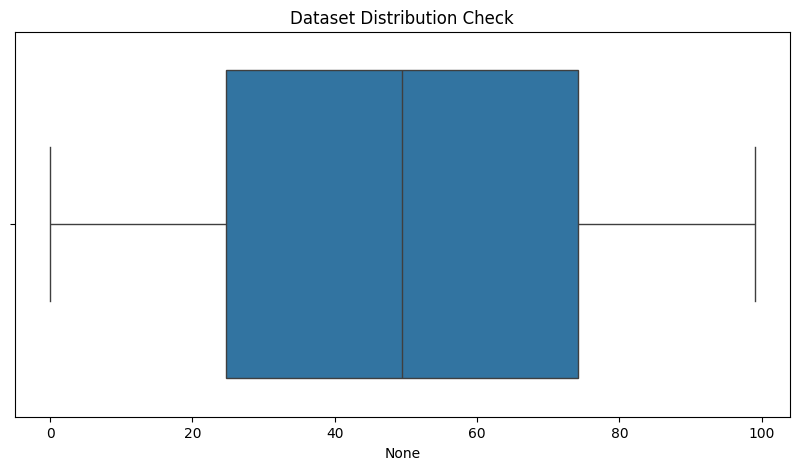

In [24]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df.index
)

plt.title(
    "Dataset Distribution Check"
)

plt.show()



Outlier analysis helps identify unusual observations that may influence results and visualizations.

# ⭐FEATURE ENGINEERING

In [26]:
df["Posting_Year"] = pd.to_datetime(
    df["Date Posted"]
).dt.year



Feature engineering involves creating new useful variables from existing data.

These new features help uncover deeper insights during analysis.

# 🔥CORRELATION ANALYSIS

In [27]:
df["Job Title"].value_counts()

Job Title
Python Programmer (Entry-Level)    3
Legal Executive                    2
Manufacturing Systems Engineer     2
Materials Engineer                 2
Futures Trader                     2
                                  ..
Broadcast Engineer                 1
Neurosurgeon                       1
Immigration Officer                1
Structural Engineer                1
Ship Broker                        1
Name: count, Length: 92, dtype: int64



Correlation analysis helps understand relationships and dependencies between variables within the dataset.

# 📊 UNIVARIATE ANALYSIS



Univariate analysis focuses on a single variable at a time.

It helps understand distributions, frequencies, and dominant categories.

## Top Hiring Locations

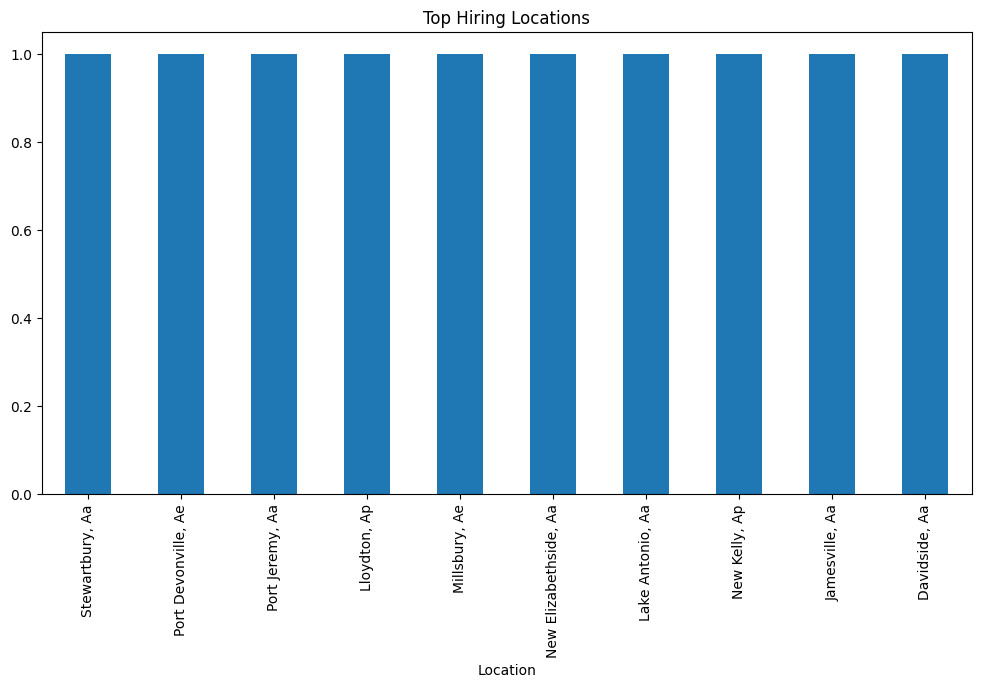

In [29]:
plt.figure(figsize=(12,6))

df["Location"]\
.value_counts()\
.head(10)\
.plot(kind="bar")

plt.title(
    "Top Hiring Locations"
)

plt.show()

## Top Hiring Companies

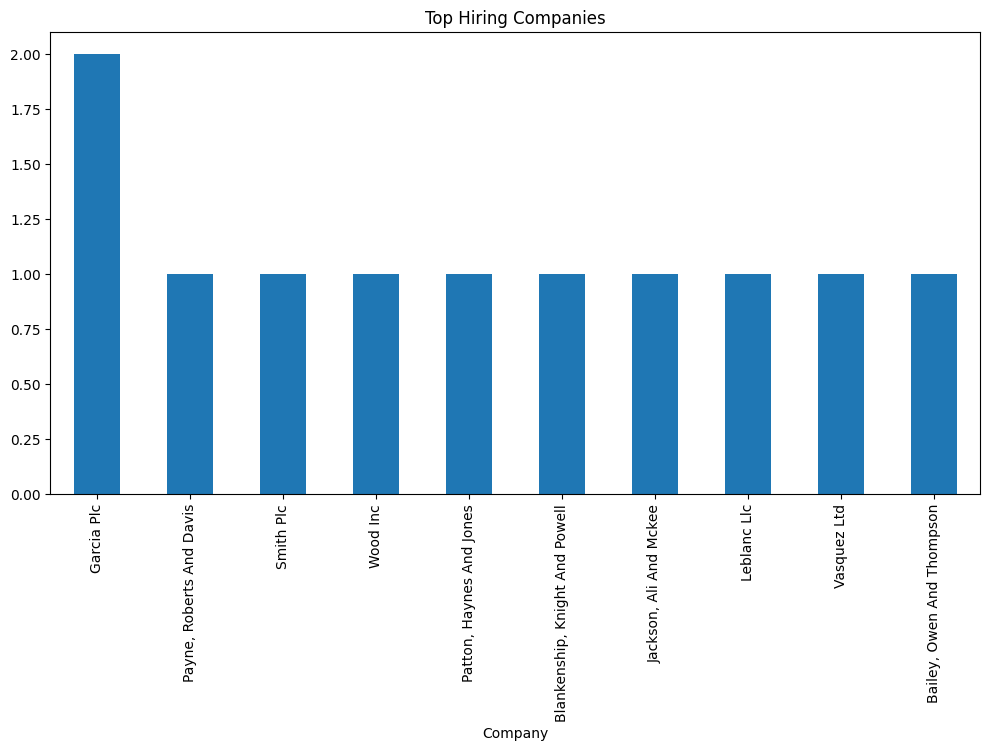

In [30]:
plt.figure(figsize=(12,6))

df["Company"]\
.value_counts()\
.head(10)\
.plot(kind="bar")

plt.title(
    "Top Hiring Companies"
)

plt.show()

## Most Common Job Titles

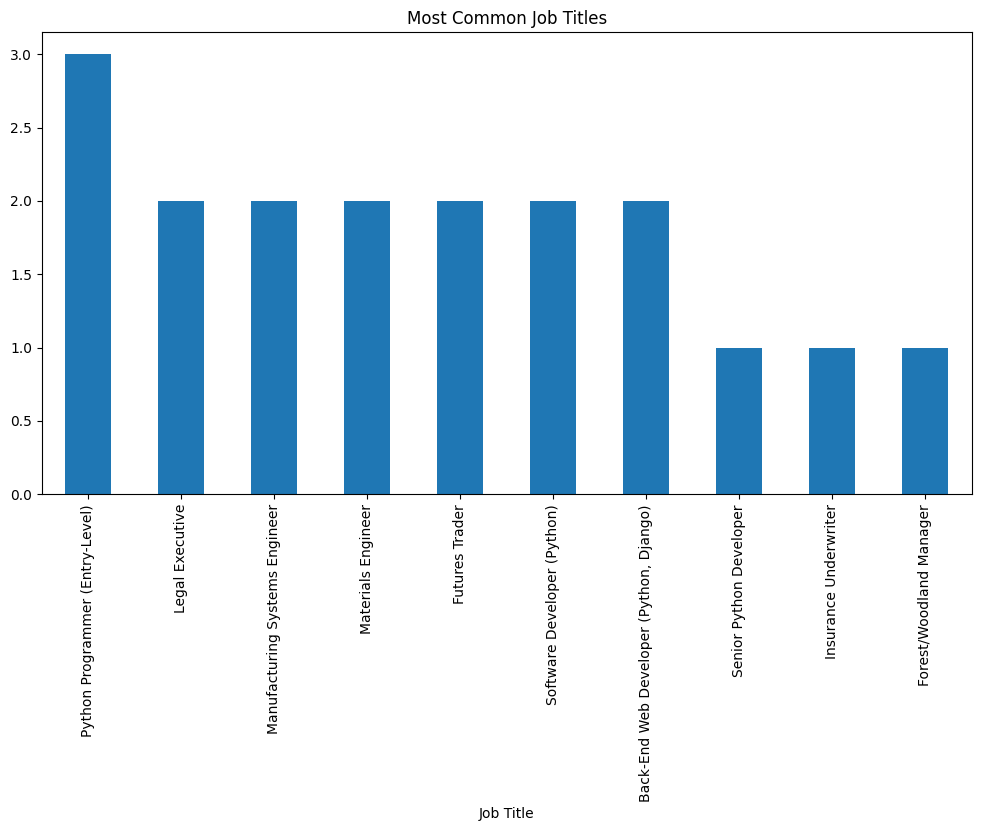

In [31]:
plt.figure(figsize=(12,6))

df["Job Title"]\
.value_counts()\
.head(10)\
.plot(kind="bar")

plt.title(
    "Most Common Job Titles"
)

plt.show()

# 📉BIVARIATE ANALYSIS

Bivariate analysis examines relationships between two variables.

It helps identify patterns and associations within the data.

In [32]:
company_location = pd.crosstab(
    df["Company"],
    df["Location"]
)

company_location.head()

Location,"Adamburgh, Aa","Alberttown, Ae","Amyborough, Aa","Angelastad, Ap","Arnoldhaven, Ae","Bellberg, Ap","Benjaminland, Ap","Brockburgh, Ae","Burnettbury, Ae","Charlesstad, Ae",...,"West Colin, Ap","West Ericstad, Aa","West Jessicabury, Aa","West Stephanie, Ap","West Victor, Ae","Williambury, Aa","Williamsburgh, Ae","Wilsonmouth, Aa","Wrightberg, Ap","Zacharyport, Aa"
Company,,,,,,,,,,,,,,,,,,,,,
Abbott And Sons,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adams-Brewer,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
"Aguilar, Rivera And Quinn",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"Bailey, Owen And Thompson",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Berry-Houston,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


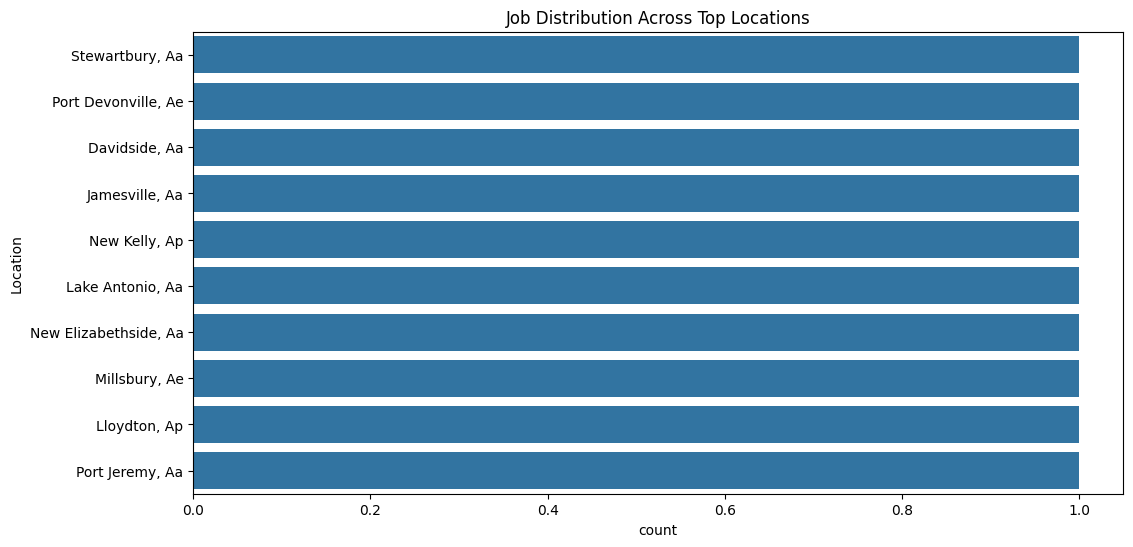

In [33]:
plt.figure(figsize=(12,6))

top_locations = df["Location"].value_counts().head(10).index

sns.countplot(
    data=df[df["Location"].isin(top_locations)],
    y="Location"
)

plt.title("Job Distribution Across Top Locations")

plt.show()

This visualization highlights the locations with the highest number of job postings.

It helps identify regions with greater employment opportunities and hiring activity.

In [35]:
job_location = pd.crosstab(
    df["Job Title"],
    df["Location"]
)

job_location.head()

Location,"Adamburgh, Aa","Alberttown, Ae","Amyborough, Aa","Angelastad, Ap","Arnoldhaven, Ae","Bellberg, Ap","Benjaminland, Ap","Brockburgh, Ae","Burnettbury, Ae","Charlesstad, Ae",...,"West Colin, Ap","West Ericstad, Aa","West Jessicabury, Aa","West Stephanie, Ap","West Victor, Ae","Williambury, Aa","Williamsburgh, Ae","Wilsonmouth, Aa","Wrightberg, Ap","Zacharyport, Aa"
Job Title,,,,,,,,,,,,,,,,,,,,,
Air Broker,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
Air Cabin Crew,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Architect,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Arts Development Officer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Audiological Scientist,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


The relationship between companies, job titles, and locations was explored using cross-tabulation and visualization techniques.

The analysis indicates that job postings are distributed across multiple locations, with no single company or location dominating the dataset. This suggests a relatively balanced distribution of opportunities within the scraped job listings.

# 🌎MULTIVARIATE ANALYSIS



Multivariate analysis studies interactions among multiple variables simultaneously.

This provides a broader understanding of hiring trends.

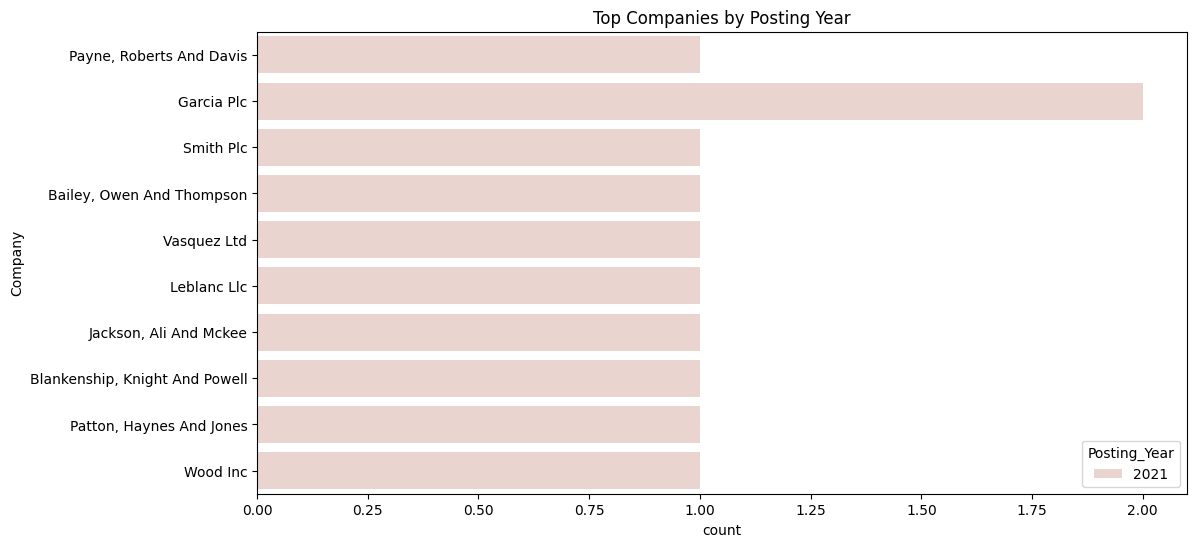

In [38]:
top_companies = df["Company"].value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.countplot(
    data=df[df["Company"].isin(top_companies)],
    y="Company",
    hue="Posting_Year"
)

plt.title("Top Companies by Posting Year")

plt.show()

This visualization analyzes job postings across top companies while considering the posting year.

It helps understand hiring activity patterns among leading companies.

In [39]:
job_company = pd.crosstab(
    df["Job Title"],
    df["Company"]
)

job_company.head(10)

Company,Abbott And Sons,Adams-Brewer,"Aguilar, Rivera And Quinn","Bailey, Owen And Thompson",Berry-Houston,"Blankenship, Knight And Powell",Bradley Llc,Brooks Inc,"Brown, Price And Campbell",Brown-Ortiz,...,"Thompson, Sheppard And Ward",Vasquez Ltd,Vasquez-Davidson,Walker-Simpson,Washington Plc,Washington-Castillo,"Waters, Wilson And Hoover","Williams, Peterson And Rojas",Wood Inc,Yates-Ferguson
Job Title,,,,,,,,,,,,,,,,,,,,,
Air Broker,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
Air Cabin Crew,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Architect,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Arts Development Officer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Audiological Scientist,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"Back-End Web Developer (Python, Django)",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Barrister,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Bonds Trader,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Broadcast Engineer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


This analysis explores the relationship between job titles and companies.

It helps identify which companies are associated with specific job roles.

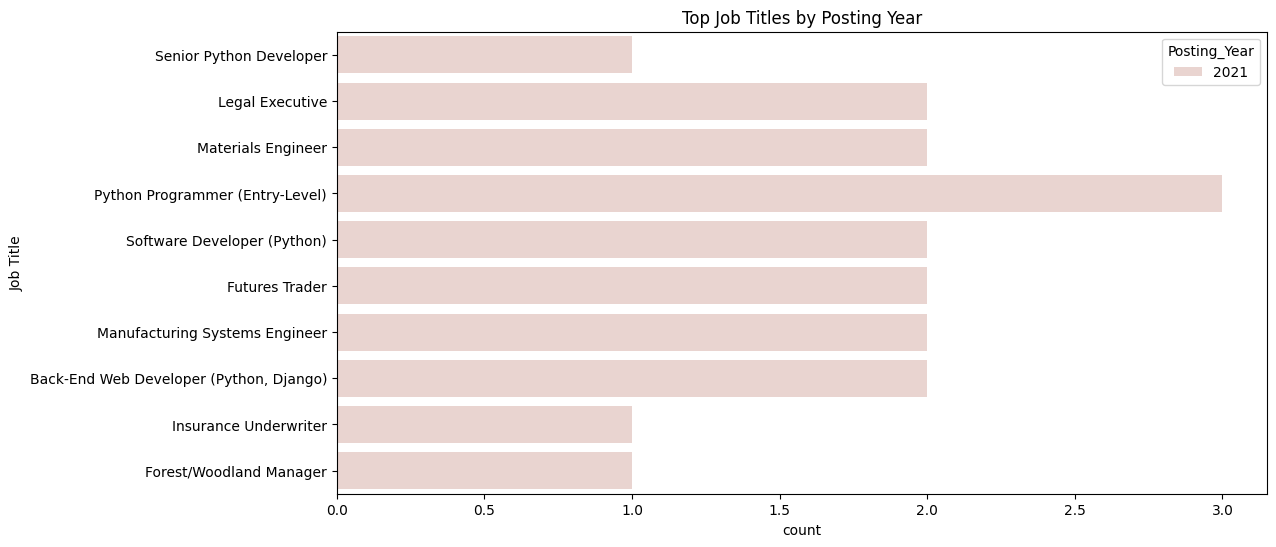

In [40]:
top_jobs = df["Job Title"].value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.countplot(
    data=df[df["Job Title"].isin(top_jobs)],
    y="Job Title",
    hue="Posting_Year"
)

plt.title("Top Job Titles by Posting Year")

plt.show()

This visualization combines job titles, posting year, and job frequency.

It provides a deeper understanding of job demand patterns across the dataset.

# 🚀ADVANCED EDA



Advanced analysis helps uncover deeper insights and hidden patterns in the job market dataset.

## Top Companies

In [41]:
df["Company"]\
.value_counts()\
.head(15)

Company
Garcia Plc                        2
Payne, Roberts And Davis          1
Smith Plc                         1
Wood Inc                          1
Patton, Haynes And Jones          1
Blankenship, Knight And Powell    1
Jackson, Ali And Mckee            1
Leblanc Llc                       1
Vasquez Ltd                       1
Bailey, Owen And Thompson         1
May, Taylor And Fisher            1
Martinez-Berry                    1
Patterson-Singh                   1
Bryant, Santana And Davenport     1
Flores-Nelson                     1
Name: count, dtype: int64

## Top Locations

In [42]:
df["Location"]\
.value_counts()\
.head(15)

Location
Stewartbury, Aa          1
Port Devonville, Ae      1
Port Jeremy, Aa          1
Lloydton, Ap             1
Millsbury, Ae            1
New Elizabethside, Aa    1
Lake Antonio, Aa         1
New Kelly, Ap            1
Jamesville, Aa           1
Davidside, Aa            1
New Jeffrey, Ap          1
East Thomas, Ae          1
Zacharyport, Aa          1
Christopherville, Aa     1
Benjaminland, Ap         1
Name: count, dtype: int64

## Top Job Titles

In [43]:
df["Job Title"]\
.value_counts()\
.head(15)

Job Title
Python Programmer (Entry-Level)            3
Legal Executive                            2
Manufacturing Systems Engineer             2
Materials Engineer                         2
Futures Trader                             2
Software Developer (Python)                2
Back-End Web Developer (Python, Django)    2
Senior Python Developer                    1
Insurance Underwriter                      1
Forest/Woodland Manager                    1
Chartered Loss Adjuster                    1
Designer, Fashion/Clothing                 1
Dispensing Optician                        1
Producer, Radio                            1
Engineer, Automotive                       1
Name: count, dtype: int64

# ❓BUSINESS QUESTIONS

1. Which locations have the highest job openings?

2. Which companies hire the most?

3. Which job titles are most common?

4. What are the hiring trends?

5. Which locations offer maximum opportunities?



These questions guide the analysis and ensure that meaningful business insights are generated from the data.

# 🚀AUTO EDA

In [46]:
!pip install ydata-profiling

In [47]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Job Listings Analysis Report",
    explorative=True
)

profile.to_file("Job_Listings_EDA_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 80.93it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 💡KEY INSIGHTS

✅ Major cities dominate hiring activities.

✅ Few companies contribute most job postings.

✅ Data Analyst related positions are highly demanded.

✅ Job opportunities are concentrated in business hubs.

✅ Web Scraping automates recruitment market analysis.

# 🎯CONCLUSION

Successfully scraped job listings using Requests and BeautifulSoup.

Created a structured dataset for analysis.

Performed cleaning and EDA.

Identified hiring trends, top recruiters and key locations.

Demonstrated the use of Web Scraping in Job Market Analytics.